## Binding Surface Distance Histogram with salt


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import glob
import os
import sklearn.cluster as clust
import sklearn.mixture as mix
import statistics
import scipy.stats 

In [2]:
simulation_len = 100000 #simulations are 1 us, saved every 10 ps
num_sims = 50 # 10 independent simulations

In [3]:
# read in the distance file from the ptraj
# Only 7 distances are being read in because they are the distances calculated from the residues that affect the bound of ArkA and SH3 the most
data_1 = resid9 = pd.read_table('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/distance_files/9-60.dat', sep=r'\s+')
data_2 = resid54 = pd.read_table('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/distance_files/54-61.dat', sep=r'\s+')
data_3 = resid53 = pd.read_table('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/distance_files/53-63.dat', sep=r'\s+')
data_4 = resid37 = pd.read_table('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/distance_files/37-66.dat', sep=r'\s+')
data_5 = resid35 = pd.read_table('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/distance_files/35-67.dat', sep=r'\s+')
data_6 = resid33 = pd.read_table('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/distance_files/33-70.dat', sep=r'\s+')
data_7 = resid15 = pd.read_table('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/distance_files/15-71.dat', sep=r'\s+')

In [4]:
binding_salt = pd.concat([eval('data_%s.iloc[:,1]' %(i)) for i in range(1, 8)], axis=1)
binding_salt

,Dis_00097,Dis_00638,Dis_00628,Dis_00439,Dis_00416,Dis_00395,Dis_00180
0,28.7747,30.4143,38.6915,36.7284,46.2233,52.6589,47.0758
1,28.6552,30.9965,38.7027,36.5623,46.8943,52.6068,46.9110
2,28.1683,31.2225,38.8511,35.7623,45.7171,51.0675,46.2057
3,29.0832,32.3450,39.0980,36.3648,46.3452,51.1588,46.0382
4,28.3263,30.7905,38.2552,35.2841,45.4652,50.6149,45.4138
...,...,...,...,...,...,...,...
4999995,12.5256,13.2822,8.4108,24.2443,22.7040,30.6697,35.8048
4999996,13.0027,13.4574,7.7561,23.6434,22.8953,30.6648,36.6967
4999997,13.2205,13.7308,7.6027,24.2358,22.8309,30.5993,37.9970
4999998,12.5028,13.0385,7.3790,24.2180,23.2603,31.9236,37.4313


In [5]:
# calculate the average across the rows 
binding_salt['avg']= binding_salt.iloc[:,0:7].mean(axis=1)
binding_salt

,Dis_00097,Dis_00638,Dis_00628,Dis_00439,Dis_00416,Dis_00395,Dis_00180,avg
0,28.7747,30.4143,38.6915,36.7284,46.2233,52.6589,47.0758,40.080986
1,28.6552,30.9965,38.7027,36.5623,46.8943,52.6068,46.9110,40.189829
2,28.1683,31.2225,38.8511,35.7623,45.7171,51.0675,46.2057,39.570643
3,29.0832,32.3450,39.0980,36.3648,46.3452,51.1588,46.0382,40.061886
4,28.3263,30.7905,38.2552,35.2841,45.4652,50.6149,45.4138,39.164286
...,...,...,...,...,...,...,...,...
4999995,12.5256,13.2822,8.4108,24.2443,22.7040,30.6697,35.8048,21.091629
4999996,13.0027,13.4574,7.7561,23.6434,22.8953,30.6648,36.6967,21.159486
4999997,13.2205,13.7308,7.6027,24.2358,22.8309,30.5993,37.9970,21.459571
4999998,12.5028,13.0385,7.3790,24.2180,23.2603,31.9236,37.4313,21.393357


In [6]:
# Calculate the stdev
binding_salt['SEM']=binding_salt.iloc[:,0:7].sem(axis=1)
binding_salt

,Dis_00097,Dis_00638,Dis_00628,Dis_00439,Dis_00416,Dis_00395,Dis_00180,avg,SEM
0,28.7747,30.4143,38.6915,36.7284,46.2233,52.6589,47.0758,40.080986,3.378175
1,28.6552,30.9965,38.7027,36.5623,46.8943,52.6068,46.9110,40.189829,3.370886
2,28.1683,31.2225,38.8511,35.7623,45.7171,51.0675,46.2057,39.570643,3.194887
3,29.0832,32.3450,39.0980,36.3648,46.3452,51.1588,46.0382,40.061886,3.059012
4,28.3263,30.7905,38.2552,35.2841,45.4652,50.6149,45.4138,39.164286,3.137101
...,...,...,...,...,...,...,...,...,...
4999995,12.5256,13.2822,8.4108,24.2443,22.7040,30.6697,35.8048,21.091629,3.829470
4999996,13.0027,13.4574,7.7561,23.6434,22.8953,30.6648,36.6967,21.159486,3.923206
4999997,13.2205,13.7308,7.6027,24.2358,22.8309,30.5993,37.9970,21.459571,4.042154
4999998,12.5028,13.0385,7.3790,24.2180,23.2603,31.9236,37.4313,21.393357,4.154211


Current dimensions: 6.4 x 4.8 inches
New dimensions: 5 x 3.7499999999999996 inches


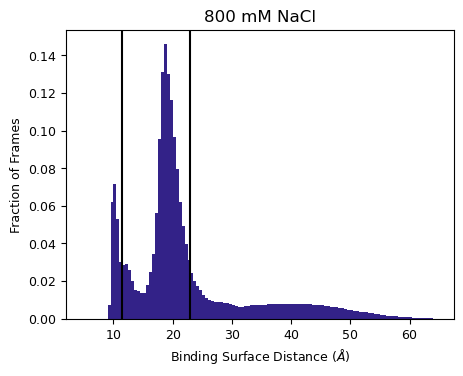

In [12]:
#for i, df in enumerate(sorted(df_dict_pairwise)):
    #print(i)
binedges = np.arange(5, 65,0.5)
hist = plt.hist(binding_salt['avg'], bins = binedges, density = 1, color="#332288", label = 'salt') #plots the x values for #Frame and th y value for avg
    #current_xticks = [0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000] # this number are used to define the x-axis and are based on the number of rows on each individual simulation distance calculated
    #my_xticks = ['0', '100', '200','300', '400','500','600','700','800','900','1000'] # converts the number f frames to timescale which is 100 ts/ns
    #plt.xticks(current_xticks, my_xticks, fontsize = 12) # plots the value in current_xticks as my_xticks
    #plt.yticks(size =12) # makes 12 the font size for the y axis
    #plt.plot([0,97500],[11.5,11.5], 'k-') # plot a horizontal line that indictes the cut off mark for the bound stage
    #plt.plot([0,97500],[23,23], 'k-') # plot a horizontal line that indictes the cut off mark for the encounter complex
    #plt.ylim(5, 65) # range of values for the y axis
    #plt.xlabel('time (ns)', size=14) # gives a name to the x-axis
plt.axvline(x = 11.5 , ymin = 0, ymax = 60, color = 'black')
plt.axvline(x = 23 , ymin = 0, ymax = 60, color = 'black')
plt.xlabel('Binding Surface Distance ($\AA$)', size =9) # gives a name to the y-axis
plt.ylabel('Fraction of Frames', size=9)
plt.title('800 mM NaCl', size=12)
    #plt.savefig('/data/oonwuzul/abp1-arka12_bound/abp1-arka_E17Q/analysis/pair_wise_distances/plots/bound_surface_distance_'+str(i+1)+'.png', dpi = 2000) # saves the plot as a pdf format. dpi represents the quality of the plot when it saves it. 
plt.xticks(size=9)
plt.yticks(size=9)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

plt.show()

## Binding Surface Distance Histogram without salt

In [13]:
# read in the distance file from the ptraj
# Only 7 distances are being read in because they are the distances calculated from the residues that affect the bound of ArkA and SH3 the most
data_1 = resid9 = pd.read_table('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/wild_distance_files/9-60.dat', sep='\s+')
data_2 = resid54 = pd.read_table('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/wild_distance_files/54-61.dat', sep='\s+')
data_3 = resid53 = pd.read_table('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/wild_distance_files/53-63.dat', sep='\s+')
data_4 = resid37 = pd.read_table('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/wild_distance_files/37-66.dat', sep='\s+')
data_5 = resid35 = pd.read_table('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/wild_distance_files/35-67.dat', sep='\s+')
data_6 = resid33 = pd.read_table('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/wild_distance_files/33-70.dat', sep='\s+')
data_7 = resid15 = pd.read_table('/data/oonwuzul/abp1-arka12_binding/abp1-arka_wild/wild_distance_files/15-71.dat', sep='\s+')

In [14]:
binding_nosalt = pd.concat([eval('data_%s.iloc[:,1]' %(i)) for i in range(1, 8)], axis=1)
binding_nosalt

,Dis_00097,Dis_00638,Dis_00628,Dis_00439,Dis_00416,Dis_00395,Dis_00180
0,31.9253,34.4935,38.6094,37.0199,46.2668,56.8996,43.5494
1,31.1675,34.2473,39.0687,37.4649,47.1893,57.3521,43.9899
2,32.6590,35.2640,40.1725,37.7839,48.0835,59.1861,45.6742
3,31.8303,33.8870,38.4850,36.2960,46.4857,57.5827,43.6321
4,32.0121,34.7567,38.3629,36.5145,46.2836,57.9486,43.4143
...,...,...,...,...,...,...,...
4999995,12.3256,13.1726,6.5983,24.2576,22.5873,20.8556,32.1164
4999996,12.0444,13.0854,6.4935,23.9133,23.3221,20.2062,30.3736
4999997,12.3749,12.9865,6.4910,22.7597,22.1513,20.6612,32.5016
4999998,11.7057,13.2036,7.0543,22.7658,22.2167,21.7427,32.6951


In [15]:
# calculate the average across the rows 
binding_nosalt['avg']= binding_nosalt.iloc[:,0:7].mean(axis=1)
binding_nosalt

,Dis_00097,Dis_00638,Dis_00628,Dis_00439,Dis_00416,Dis_00395,Dis_00180,avg
0,31.9253,34.4935,38.6094,37.0199,46.2668,56.8996,43.5494,41.251986
1,31.1675,34.2473,39.0687,37.4649,47.1893,57.3521,43.9899,41.497100
2,32.6590,35.2640,40.1725,37.7839,48.0835,59.1861,45.6742,42.689029
3,31.8303,33.8870,38.4850,36.2960,46.4857,57.5827,43.6321,41.171257
4,32.0121,34.7567,38.3629,36.5145,46.2836,57.9486,43.4143,41.327529
...,...,...,...,...,...,...,...,...
4999995,12.3256,13.1726,6.5983,24.2576,22.5873,20.8556,32.1164,18.844771
4999996,12.0444,13.0854,6.4935,23.9133,23.3221,20.2062,30.3736,18.491214
4999997,12.3749,12.9865,6.4910,22.7597,22.1513,20.6612,32.5016,18.560886
4999998,11.7057,13.2036,7.0543,22.7658,22.2167,21.7427,32.6951,18.769129


In [16]:
# Calculate the stdev
binding_nosalt['SEM']=binding_nosalt.iloc[:,0:7].sem(axis=1)
binding_nosalt

,Dis_00097,Dis_00638,Dis_00628,Dis_00439,Dis_00416,Dis_00395,Dis_00180,avg,SEM
0,31.9253,34.4935,38.6094,37.0199,46.2668,56.8996,43.5494,41.251986,3.210223
1,31.1675,34.2473,39.0687,37.4649,47.1893,57.3521,43.9899,41.497100,3.350239
2,32.6590,35.2640,40.1725,37.7839,48.0835,59.1861,45.6742,42.689029,3.437506
3,31.8303,33.8870,38.4850,36.2960,46.4857,57.5827,43.6321,41.171257,3.362725
4,32.0121,34.7567,38.3629,36.5145,46.2836,57.9486,43.4143,41.327529,3.334825
...,...,...,...,...,...,...,...,...,...
4999995,12.3256,13.1726,6.5983,24.2576,22.5873,20.8556,32.1164,18.844771,3.266475
4999996,12.0444,13.0854,6.4935,23.9133,23.3221,20.2062,30.3736,18.491214,3.130488
4999997,12.3749,12.9865,6.4910,22.7597,22.1513,20.6612,32.5016,18.560886,3.252465
4999998,11.7057,13.2036,7.0543,22.7658,22.2167,21.7427,32.6951,18.769129,3.268676


Current dimensions: 6.4 x 4.8 inches
New dimensions: 5 x 3.7499999999999996 inches


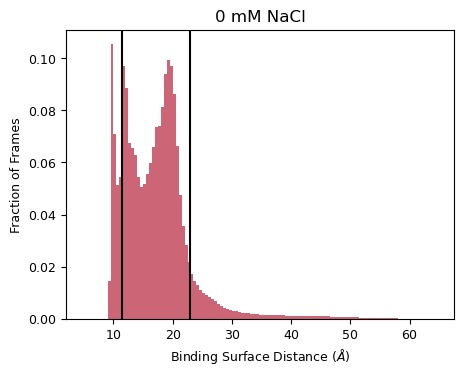

In [18]:
#for i, df in enumerate(sorted(df_dict_pairwise)):
    #print(i)
binedges = np.arange(5, 65,0.5)
hist = plt.hist(binding_nosalt['avg'], bins = binedges, density = 1, color="#CC6677", label = 'no salt') #plots the x values for #Frame and th y value for avg
    #current_xticks = [0,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000] # this number are used to define the x-axis and are based on the number of rows on each individual simulation distance calculated
    #my_xticks = ['0', '100', '200','300', '400','500','600','700','800','900','1000'] # converts the number f frames to timescale which is 100 ts/ns
    #plt.xticks(current_xticks, my_xticks, fontsize = 12) # plots the value in current_xticks as my_xticks
    #plt.yticks(size =12) # makes 12 the font size for the y axis
    #plt.plot([0,97500],[11.5,11.5], 'k-') # plot a horizontal line that indictes the cut off mark for the bound stage
    #plt.plot([0,97500],[23,23], 'k-') # plot a horizontal line that indictes the cut off mark for the encounter complex
    #plt.ylim(5, 65) # range of values for the y axis
    #plt.xlabel('time (ns)', size=14) # gives a name to the x-axis
plt.axvline(x = 11.5 , ymin = 0, ymax = 60, color = 'black')
plt.axvline(x = 23 , ymin = 0, ymax = 60, color = 'black')
plt.xlabel('Binding Surface Distance ($\AA$)', size =9) # gives a name to the y-axis
plt.ylabel('Fraction of Frames', size=9)
plt.title('0 mM NaCl', size=12)
    #plt.savefig('/data/oonwuzul/abp1-arka12_bound/abp1-arka_E17Q/analysis/pair_wise_distances/plots/bound_surface_distance_'+str(i+1)+'.png', dpi = 2000) # saves the plot as a pdf format. dpi represents the quality of the plot when it saves it. 

plt.xticks(size=9)
plt.yticks(size=9)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

plt.show()